In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8-whitegrid')
 
COLORS = ['#E24B4A', '#1D9E75', '#378ADD', '#BA7517', '#7F77DD']
CLUSTER_NAMES = [
    'Careful Spenders (Low Income, Low Spend)',
    'Standard Segment (Moderate Income & Spend)',
    'Impulse Buyers (Low Income, High Spend)',
    'Premium Customers (High Income, High Spend)',
    'Conservative Affluent (High Income, Low Spend)',
]

In [3]:
def load_data(filepath='Mall_Customers.csv'):
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"\n[ERROR] '{filepath}' not found.\n"
            "Download from: https://www.kaggle.com/datasets/"
            "vjchoudhary7/customer-segmentation-tutorial-in-python\n"
        )
 
    df.columns = df.columns.str.strip()   # remove hidden spaces
 
    print("=" * 55)
    print("  CUSTOMER SEGMENTATION — K-MEANS CLUSTERING")
    print("=" * 55)
    print(f"\nColumns found : {list(df.columns)}")
    print(f"Shape         : {df.shape[0]} rows x {df.shape[1]} columns\n")
    print(df.head())
    return df
 

In [4]:
def fix_columns(df):
    """
    Rename columns to fixed standard names regardless of CSV version.
    Handles 'Genre' vs 'Gender', different income/score spellings, etc.
    """
    df = df.copy()
    df.columns = df.columns.str.strip()
 
    rename = {}
    for col in df.columns:
        low = col.lower().strip()
        if low in ('genre', 'gender', 'sex'):
            rename[col] = 'Gender'
        elif 'income' in low:
            rename[col] = 'Annual_Income'
        elif 'spending' in low or 'score' in low:
            rename[col] = 'Spending_Score'
        elif low == 'age':
            rename[col] = 'Age'
        elif 'customerid' in low or low == 'id':
            rename[col] = 'CustomerID'
 
    df.rename(columns=rename, inplace=True)
    print(f"\n[2] Standardised columns: {list(df.columns)}")
    return df
 

In [5]:
def run_eda(df):
    print("\n[3] Missing Values:")
    print(df.isnull().sum())
    print("\n[3] Descriptive Statistics:")
    print(df.describe().round(2))
 
    # Distribution plots
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
    cols    = ['Age', 'Annual_Income', 'Spending_Score']
    palette = ['#378ADD', '#1D9E75', '#E24B4A']
    for ax, col, color in zip(axes, cols, palette):
        sns.histplot(df[col], kde=True, ax=ax, color=color, bins=20)
        ax.set_title(col)
        ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig('01_feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 01_feature_distributions.png")
 
    # Gender bar chart
    fig, ax = plt.subplots(figsize=(5, 4))
    counts = df['Gender'].value_counts()
    ax.bar(counts.index, counts.values,
           color=['#378ADD', '#E24B4A'], edgecolor='white', width=0.5)
    ax.set_title('Gender Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig('02_gender_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 02_gender_distribution.png")

In [6]:
def preprocess(df):
    df = df.copy()
    df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})
 
    X = df[['Annual_Income', 'Spending_Score']]
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
 
    print(f"\n[4] Features : Annual_Income, Spending_Score")
    print(f"    Shape    : {X_scaled.shape}")
    return df, X, X_scaled, scaler

In [7]:
def elbow_method(X_scaled, max_k=10):
    wcss = []
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
        km.fit(X_scaled)
        wcss.append(km.inertia_)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, max_k + 1), wcss, marker='o', color='#378ADD',
            linewidth=2.5, markersize=8)
    ax.axvline(x=5, color='#E24B4A', linestyle='--',
               linewidth=1.8, label='Optimal K = 5')
    ax.scatter([5], [wcss[4]], color='#E24B4A', s=120, zorder=5)
    ax.set_title('Elbow Method — Finding Optimal K',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=11)
    ax.set_ylabel('WCSS', fontsize=11)
    ax.legend()
    ax.set_xticks(range(1, max_k + 1))
    plt.tight_layout()
    plt.savefig('03_elbow_method.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n[5] Saved: 03_elbow_method.png")
    print(f"    WCSS  : {[round(w, 1) for w in wcss]}")
    print("    Optimal K = 5")
    return wcss
 
 

In [8]:
def train_kmeans(X_scaled, n_clusters=5):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    print(f"\n[6] K-Means trained  |  K={n_clusters}")
    print(f"    Inertia (WCSS)   : {kmeans.inertia_:.2f}")
    print(f"    Silhouette Score : {sil:.4f}  (good if > 0.5)")
    return kmeans

In [9]:
def assign_clusters(df, X_scaled, kmeans, scaler):
    df = df.copy()
    df['Cluster_Raw'] = kmeans.labels_
 
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
 
    print("\n[7] Cluster Centroids (original scale):")
    print(f"    {'Cluster':<10} {'Avg Income (k)':<20} {'Avg Spending Score'}")
    for i, c in enumerate(centers):
        print(f"    {i:<10} {c[0]:<20.1f} {c[1]:.1f}")
 
    # Remap raw cluster IDs by ascending income order → consistent labels
    order = np.argsort(centers[:, 0])   # sort by income ascending
    remap = {raw: new for new, raw in enumerate(order)}
    df['Cluster']      = df['Cluster_Raw'].map(remap)
    df['Cluster_Name'] = df['Cluster'].map(
        {i: name for i, name in enumerate(CLUSTER_NAMES)}
    )
 
    print("\n[7] Customer counts per cluster:")
    for i, name in enumerate(CLUSTER_NAMES):
        n = (df['Cluster'] == i).sum()
        print(f"    Cluster {i}: {n:>3} customers  —  {name}")
 
    return df, centers

In [10]:
def plot_scatter(df, kmeans, scaler):
    fig, ax = plt.subplots(figsize=(10, 7))
    for i in range(5):
        mask = df['Cluster'] == i
        ax.scatter(df.loc[mask, 'Annual_Income'],
                   df.loc[mask, 'Spending_Score'],
                   s=70, c=COLORS[i], alpha=0.85,
                   label=CLUSTER_NAMES[i],
                   edgecolors='white', linewidths=0.4)
 
    c_orig = scaler.inverse_transform(kmeans.cluster_centers_)
    ax.scatter(c_orig[:, 0], c_orig[:, 1], s=220, c='black',
               marker='X', label='Centroids', zorder=10,
               edgecolors='white', linewidths=0.8)
 
    ax.set_title('Customer Segments — Annual Income vs Spending Score',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Annual Income (k$)', fontsize=12)
    ax.set_ylabel('Spending Score (1-100)', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()
    plt.savefig('04_cluster_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 04_cluster_scatter.png")
 
 
def plot_boxplots(df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Cluster Distributions', fontsize=13, fontweight='bold')
    for ax, col, title in zip(
        axes,
        ['Annual_Income', 'Spending_Score'],
        ['Annual Income (k$)', 'Spending Score (1-100)']
    ):
        data = [df.loc[df['Cluster'] == c, col].values for c in range(5)]
        bp   = ax.boxplot(data, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
        for patch, color in zip(bp['boxes'], COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        ax.set_xticklabels([f'C{i}' for i in range(5)])
        ax.set_title(title)
        ax.set_xlabel('Cluster')
    plt.tight_layout()
    plt.savefig('05_cluster_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 05_cluster_boxplots.png")
 
 
def plot_heatmap(df):
    summary      = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
    summary_norm = (summary - summary.min()) / (summary.max() - summary.min())
 
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(summary_norm.T, annot=summary.T, fmt='.1f',
                cmap='YlOrRd', ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Normalised value'})
    ax.set_title('Cluster Profile Heatmap (mean values)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xticklabels([f'Cluster {i}' for i in range(5)], rotation=30)
    ax.set_yticklabels(['Age', 'Annual Income', 'Spending Score'], rotation=0)
    plt.tight_layout()
    plt.savefig('06_cluster_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 06_cluster_heatmap.png")
 
 
def plot_pairplot(df):
    pair_df = df[['Age', 'Annual_Income', 'Spending_Score', 'Cluster']].copy()
    pair_df['Cluster'] = pair_df['Cluster'].astype(str)
    g = sns.pairplot(pair_df, hue='Cluster',
                     palette={str(i): COLORS[i] for i in range(5)},
                     plot_kws=dict(alpha=0.7, s=35),
                     diag_kind='kde')
    g.fig.suptitle('Pair Plot — All Features by Cluster',
                   y=1.02, fontsize=13, fontweight='bold')
    plt.savefig('07_pairplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Saved: 07_pairplot.png")
 

In [11]:
def export_results(df):
    out = 'customer_segments_output.csv'
    df.to_csv(out, index=False)
    print(f"\n[9] Saved: {out}")
    print(df[['CustomerID', 'Gender', 'Age', 'Annual_Income',
              'Spending_Score', 'Cluster', 'Cluster_Name']].head(10).to_string(index=False))

In [12]:
def print_insights(df):
    strategies = [
        "Economy bundles, referral discounts, value-for-money messaging",
        "Mainstream promotions, loyalty points — largest segment",
        "Flash sales, EMI plans, reward points — high churn risk",
        "VIP loyalty programs, early access — highest lifetime value",
        "Trust-building campaigns, premium demos, upsell with guarantees",
    ]
    print("\n" + "=" * 55)
    print("  BUSINESS INSIGHTS PER SEGMENT")
    print("=" * 55)
    for i, (name, strat) in enumerate(zip(CLUSTER_NAMES, strategies)):
        n = (df['Cluster'] == i).sum()
        print(f"\n  Cluster {i} — {name}")
        print(f"    Customers : {n}")
        print(f"    Strategy  : {strat}")
 
 

  CUSTOMER SEGMENTATION — K-MEANS CLUSTERING

Columns found : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape         : 200 rows x 5 columns

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

[2] Standardised columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

[3] Missing Values:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

[3] Descriptive Statistics:
       CustomerID     Age  Annual_Income  Spending_Score
count      200.00  200.00         200.00          200.00
mean       100.50   38.

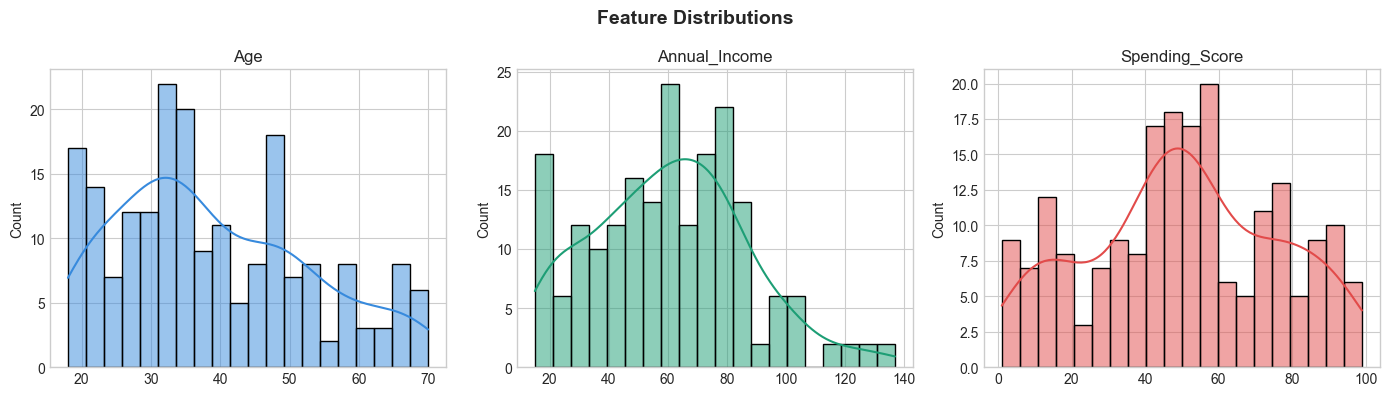

   Saved: 01_feature_distributions.png


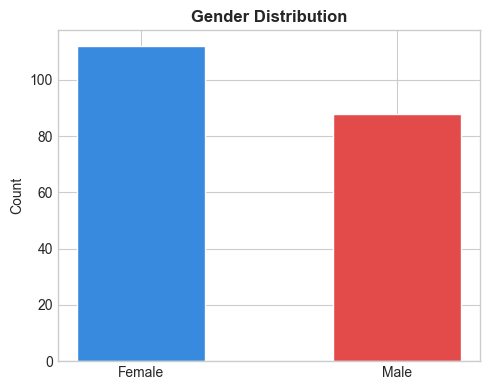

   Saved: 02_gender_distribution.png

[4] Features : Annual_Income, Spending_Score
    Shape    : (200, 2)


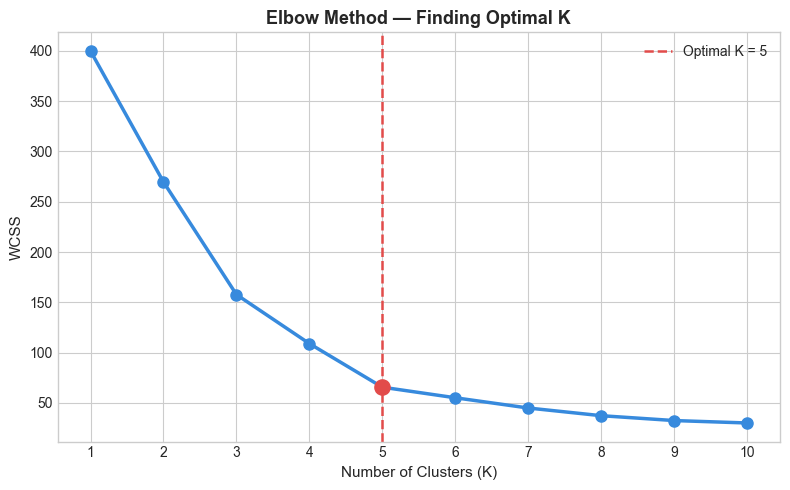


[5] Saved: 03_elbow_method.png
    WCSS  : [400.0, 269.7, 157.7, 108.9, 65.6, 55.1, 44.9, 37.2, 32.4, 30.0]
    Optimal K = 5

[6] K-Means trained  |  K=5
    Inertia (WCSS)   : 65.57
    Silhouette Score : 0.5547  (good if > 0.5)

[7] Cluster Centroids (original scale):
    Cluster    Avg Income (k)       Avg Spending Score
    0          55.3                 49.5
    1          86.5                 82.1
    2          25.7                 79.4
    3          88.2                 17.1
    4          26.3                 20.9

[7] Customer counts per cluster:
    Cluster 0:  22 customers  —  Careful Spenders (Low Income, Low Spend)
    Cluster 1:  23 customers  —  Standard Segment (Moderate Income & Spend)
    Cluster 2:  81 customers  —  Impulse Buyers (Low Income, High Spend)
    Cluster 3:  39 customers  —  Premium Customers (High Income, High Spend)
    Cluster 4:  35 customers  —  Conservative Affluent (High Income, Low Spend)

[8] Generating plots...


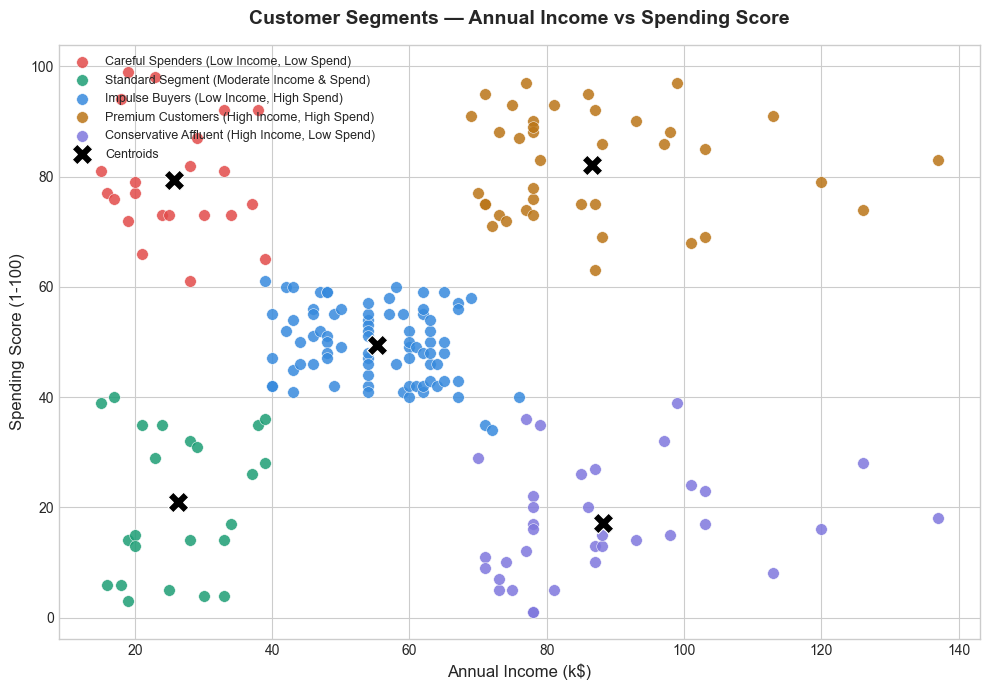

   Saved: 04_cluster_scatter.png


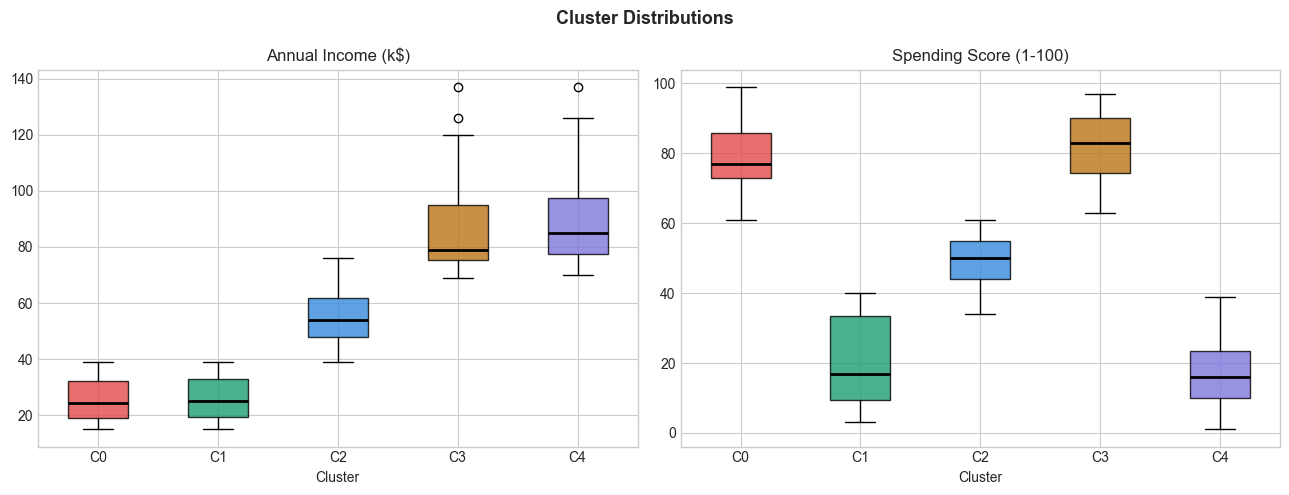

   Saved: 05_cluster_boxplots.png


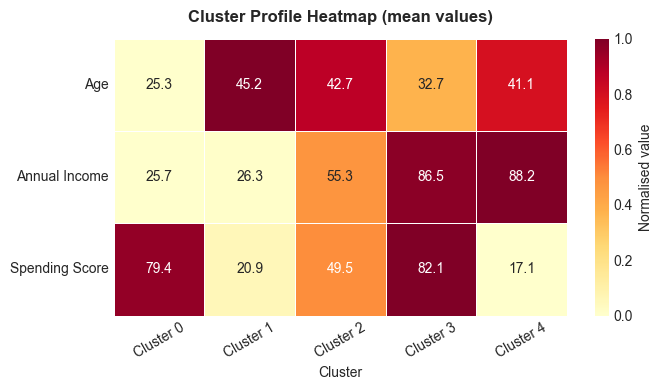

   Saved: 06_cluster_heatmap.png


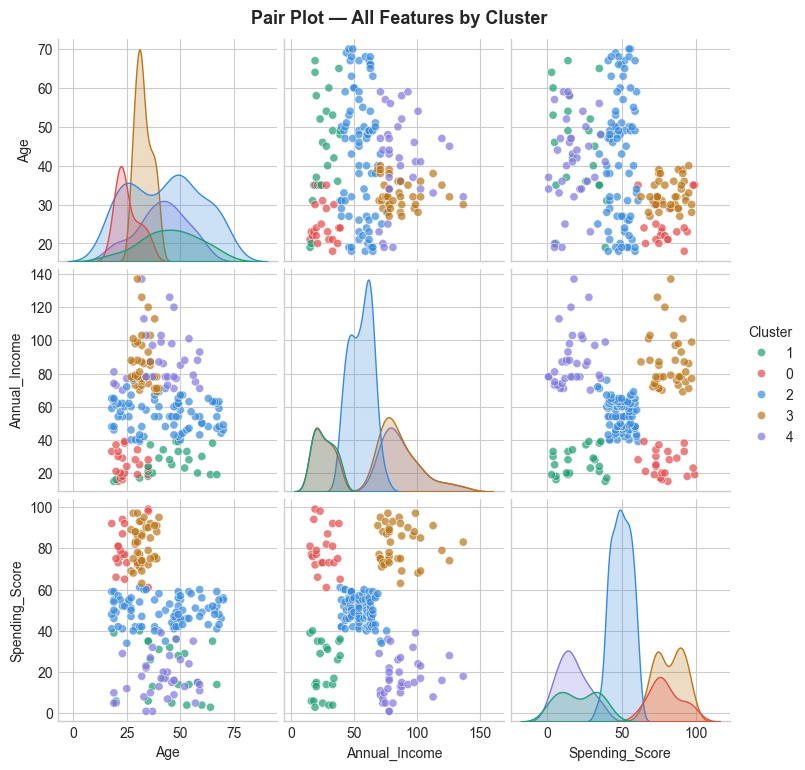

   Saved: 07_pairplot.png

[9] Saved: customer_segments_output.csv
 CustomerID Gender  Age  Annual_Income  Spending_Score  Cluster                               Cluster_Name
          1   Male   19             15              39        1 Standard Segment (Moderate Income & Spend)
          2   Male   21             15              81        0   Careful Spenders (Low Income, Low Spend)
          3 Female   20             16               6        1 Standard Segment (Moderate Income & Spend)
          4 Female   23             16              77        0   Careful Spenders (Low Income, Low Spend)
          5 Female   31             17              40        1 Standard Segment (Moderate Income & Spend)
          6 Female   22             17              76        0   Careful Spenders (Low Income, Low Spend)
          7 Female   35             18               6        1 Standard Segment (Moderate Income & Spend)
          8 Female   23             18              94        0   Careful Spe

In [13]:
def main():
    df = load_data('Mall_Customers.csv')            # Step 1
    df = fix_columns(df)                            # Step 2
    run_eda(df)                                     # Step 3
    df, X, X_scaled, scaler = preprocess(df)        # Step 4
    elbow_method(X_scaled)                          # Step 5
    kmeans = train_kmeans(X_scaled)                 # Step 6
    df, centers = assign_clusters(df, X_scaled, kmeans, scaler)  # Step 7
 
    print("\n[8] Generating plots...")
    plot_scatter(df, kmeans, scaler)
    plot_boxplots(df)
    plot_heatmap(df)
    plot_pairplot(df)
 
    export_results(df)                              # Step 9
    print_insights(df)                              # Step 10
 
    print("\n" + "=" * 55)
    print("  DONE — all plots & CSV saved in this folder!")
    print("=" * 55)
 
 
if __name__ == '__main__':
    main()
 

In [14]:
# ============================================================
#  CLUSTER EVALUATION — Run this as a standalone cell
#  Make sure Mall_Customers.csv is in your working directory
# ============================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)

# ── 1. Load & fix columns ────────────────────────────────────
df = pd.read_csv('Mall_Customers.csv')
df.columns = df.columns.str.strip()

rename = {}
for col in df.columns:
    low = col.lower().strip()
    if low in ('genre', 'gender', 'sex'):
        rename[col] = 'Gender'
    elif 'income' in low:
        rename[col] = 'Annual_Income'
    elif 'spending' in low or 'score' in low:
        rename[col] = 'Spending_Score'
df.rename(columns=rename, inplace=True)

# ── 2. Scale features ────────────────────────────────────────
X        = df[['Annual_Income', 'Spending_Score']]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. Train K-Means (K=5) ───────────────────────────────────
kmeans = KMeans(n_clusters=5, init='k-means++',
                max_iter=300, n_init=10, random_state=42)
kmeans.fit(X_scaled)

# ── 4. Evaluate ──────────────────────────────────────────────
labels = kmeans.labels_

sil  = silhouette_score(X_scaled, labels)
db   = davies_bouldin_score(X_scaled, labels)
ch   = calinski_harabasz_score(X_scaled, labels)
wcss = kmeans.inertia_

print("=" * 50)
print("       CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"  Silhouette Score        : {sil:.4f}")
print(f"  (higher is better, max = 1.0)")
print()
print(f"  Davies-Bouldin Index    : {db:.4f}")
print(f"  (lower is better, min = 0.0)")
print()
print(f"  Calinski-Harabasz Score : {ch:.2f}")
print(f"  (higher is better)")
print()
print(f"  Inertia / WCSS          : {wcss:.2f}")
print(f"  (lower is better)")
print("=" * 50)
print()

# ── 5. Interpretation ────────────────────────────────────────
print("  INTERPRETATION")
print("-" * 50)

if sil >= 0.5:
    print(f"  Silhouette {sil:.2f} → GOOD cluster separation")
elif sil >= 0.25:
    print(f"  Silhouette {sil:.2f} → FAIR cluster separation")
else:
    print(f"  Silhouette {sil:.2f} → WEAK cluster separation")

if db <= 0.8:
    print(f"  Davies-Bouldin {db:.2f} → GOOD (clusters are distinct)")
elif db <= 1.5:
    print(f"  Davies-Bouldin {db:.2f} → FAIR")
else:
    print(f"  Davies-Bouldin {db:.2f} → WEAK (clusters overlap)")

print()
print("  NOTE: K-Means has no 'accuracy %' because it is")
print("  unsupervised (no true labels). Silhouette Score")
print(f"  of {sil*100:.1f}% is the closest equivalent metric.")
print("=" * 50)

       CLUSTER QUALITY METRICS
  Silhouette Score        : 0.5547
  (higher is better, max = 1.0)

  Davies-Bouldin Index    : 0.5722
  (lower is better, min = 0.0)

  Calinski-Harabasz Score : 248.65
  (higher is better)

  Inertia / WCSS          : 65.57
  (lower is better)

  INTERPRETATION
--------------------------------------------------
  Silhouette 0.55 → GOOD cluster separation
  Davies-Bouldin 0.57 → GOOD (clusters are distinct)

  NOTE: K-Means has no 'accuracy %' because it is
  unsupervised (no true labels). Silhouette Score
  of 55.5% is the closest equivalent metric.
